# Spatial Classification - ResNet18 with Tile Classification and Majority Voting

This notebook evaluates an ImageNet-pretrained ResNet18 for spatial grain-variety classification using selected hyperspectral bands.

Five models are examined - for either one or three retained bands, with three RGB bands serving as a baseline for other 3-band subsets to be compared to.

Here, we want to try and answer:
> Can spatial information compensate for reduced spectral information?

Each source image is divided into 16 non-overlapping tiles. ResNet18 classifies every tile independently using the source-image variety label, with one cross-entropy loss calculated per tile

The final source-image prediction is obtained by majority voting across the 16 tile predictions, with mean class probabilities used to resolve ties. Hyperparameters are selected using the validation set, while the test set remains untouched until final evaluation

In [ ]:
# Imports reproducibility device and output setup

import copy
import gc
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from itertools import product

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    ResNet18_Weights,
    resnet18
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from hsi_utils import (
    build_foreground_mask_auto,
    load_cube,
    load_data
)


SEED = 42
GPU_INDEX = 0


def seed_everything(seed=SEED):
    """Set all random seeds"""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


if torch.cuda.is_available():
    if GPU_INDEX >= torch.cuda.device_count():
        raise RuntimeError(
            f"Requested GPU {GPU_INDEX} but only "
            f"{torch.cuda.device_count()} CUDA devices are visible"
        )

    torch.cuda.set_device(GPU_INDEX)

    device = torch.device(
        f"cuda:{GPU_INDEX}"
    )

else:
    device = torch.device("cpu")


PIN_MEMORY = device.type == "cuda"
NUM_WORKERS = 0


RESULTS_DIR = Path(
    "spatial_results_resnet18_image_level"
)

MODEL_DIR = (
    RESULTS_DIR
    / "models"
)

PREDICTION_DIR = (
    RESULTS_DIR
    / "predictions"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)


for directory in [
    RESULTS_DIR,
    MODEL_DIR,
    PREDICTION_DIR,
    FIGURE_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(
            device
        )
    )

Python: /data/r1032016/miniconda3/envs/grain-venv/bin/python
PyTorch version: 2.6.0+cu124
CUDA available: True
Selected device: cuda:0
Pin memory: True
DataLoader workers: 0
GPU: NVIDIA GeForce GTX 1080 Ti


In [ ]:
# Load the dataset and verify the image-level split

varieties = [
    "barley",
    "corn",
    "flax"
]

DATASET_ROOT = Path(
    "/data/r1032016/dataset"
)


if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: "
        f"{DATASET_ROOT}"
    )


(
    train_files,
    valid_files,
    test_files,
    files_split
) = load_data(
    mode="direct",
    dataset_path=DATASET_ROOT,
    varieties=tuple(varieties)
)


class_to_idx = {
    name: index
    for index, name
    in enumerate(varieties)
}

idx_to_class = {
    index: name
    for name, index
    in class_to_idx.items()
}


required_columns = {
    "sample_name",
    "variety",
    "size",
    "rep",
    "split",
    "filepath_FX10"
}

missing_columns = (
    required_columns
    - set(files_split.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: "
        f"{sorted(missing_columns)}"
    )


train_files = (
    train_files
    .reset_index(drop=True)
    .copy()
)

valid_files = (
    valid_files
    .reset_index(drop=True)
    .copy()
)

test_files = (
    test_files
    .reset_index(drop=True)
    .copy()
)


def split_value_set(
    dataframe,
    column
):
    """Return unique split values"""

    return set(
        dataframe[column]
        .astype(str)
    )


for column in [
    "sample_name",
    "filepath_FX10"
]:
    train_values = split_value_set(
        train_files,
        column
    )

    valid_values = split_value_set(
        valid_files,
        column
    )

    test_values = split_value_set(
        test_files,
        column
    )

    assert train_values.isdisjoint(
        valid_values
    )

    assert train_values.isdisjoint(
        test_values
    )

    assert valid_values.isdisjoint(
        test_values
    )


train_repetitions = split_value_set(
    train_files,
    "rep"
)

valid_repetitions = split_value_set(
    valid_files,
    "rep"
)

test_repetitions = split_value_set(
    test_files,
    "rep"
)


assert train_repetitions.isdisjoint(
    valid_repetitions
)

assert train_repetitions.isdisjoint(
    test_repetitions
)

assert valid_repetitions.isdisjoint(
    test_repetitions
)


print(
    "Training images:",
    len(train_files)
)

print(
    "Validation images:",
    len(valid_files)
)

print(
    "Test images:",
    len(test_files)
)

print(
    "Training repetitions:",
    sorted(train_repetitions)
)

print(
    "Validation repetitions:",
    sorted(valid_repetitions)
)

print(
    "Test repetitions:",
    sorted(test_repetitions)
)


display(
    pd.crosstab(
        [
            files_split["split"],
            files_split["variety"]
        ],
        files_split["size"]
    )
)

Loading remote data from: /data/r1032016/dataset
[OK] Found dataset: /data/r1032016/dataset
[OK] Detected nested dataset layout: raw/FX10
Sample files:
   raw/calibration/FX10/calibration_1705_3.hdf5
   raw/calibration/FX10/calibration_1705_2.hdf5
   raw/calibration/FX10/calibration_1705_1.hdf5
   raw/calibration/FX10/calibration_1705a_1.hdf5
   raw/calibration/FX10/calibration_1705a_3.hdf5
   raw/calibration/FX10/calibration_1705a_0.hdf5
   raw/calibration/FX10/calibration_1705a_2.hdf5
   raw/calibration/FX10/calibration_1705_0.hdf5
   raw/calibration/Snapshot/processed/calibration_1705a_2/image_0000000001.hdr
   raw/calibration/Snapshot/processed/calibration_1705_3/image_0000000003.hdr
ROOT:     /data/r1032016/dataset
Basepath: /data/r1032016/dataset/raw/FX10
OUTDIR:   /data/r1032016/dataset/processed/quickrun
Total .hdf5 files found: 45
Valid HDF5 files: 45
Invalid/unreadable files: 0

Train images: 27
Validation images: 9
Test images: 9
Device retained from setup: cuda:0


/data/r1032016/Grain-Variety-Classification/hsi_utils.py:496: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_split)


,sample_name,variety,size,rep,split,filepath_FX10
0,barley_l0,barley,l,0,train,/data/r1032016/dataset/raw/FX10/barley_l0.hdf5
1,barley_l1,barley,l,1,train,/data/r1032016/dataset/raw/FX10/barley_l1.hdf5
2,barley_l2,barley,l,2,train,/data/r1032016/dataset/raw/FX10/barley_l2.hdf5
3,barley_l3,barley,l,3,valid,/data/r1032016/dataset/raw/FX10/barley_l3.hdf5
4,barley_l4,barley,l,4,test,/data/r1032016/dataset/raw/FX10/barley_l4.hdf5


In [ ]:
# Wavelength configurations for the five spatial CNN models
EXPERIMENTS = {
    "PCA 1-band CNN": [491.9],
    "VIP 1-band CNN": [497.2],

    "PCA 3-band CNN": [491.9, 611.9, 641.6],
    "VIP 3-band CNN": [497.2, 609.2, 641.6],

    "RGB 3-band CNN": [650.0, 530.0, 450.0]
}

for experiment_name, target_wavelengths in EXPERIMENTS.items():
    print(
        f"{experiment_name}: "
        f"{target_wavelengths} nm"
    )

PCA 1-band CNN: [491.9] nm
VIP 1-band CNN: [497.2] nm
PCA 3-band CNN: [491.9, 611.9, 641.6] nm
VIP 3-band CNN: [497.2, 609.2, 641.6] nm
RGB 3-band CNN: [650.0, 530.0, 450.0] nm


In [ ]:
# Load the unique wavelengths required across all experiments.
UNIQUE_TARGET_WAVELENGTHS = sorted({
    float(wavelength)
    for wavelength_list
    in EXPERIMENTS.values()
    for wavelength
    in wavelength_list
})

WAVELENGTH_TO_POSITION = {
    wavelength: position
    for position, wavelength
    in enumerate(
        UNIQUE_TARGET_WAVELENGTHS
    )
}


def load_unique_band_image(
    filepath,
    crop=True,
    size=None,
):
    """
    Load the required wavelength bands and compute the
    foreground mask for the image.
    """
    (
        hcube,
        wlens,
        darkref,
        whiteref
    ) = load_cube(filepath)

    if crop:
        hcube = hcube[
            75:1025,
            100:875,
            :
        ]

    band_indices = [
        int(
            np.argmin(
                np.abs(wlens - wavelength)
            )
        )
        for wavelength
        in UNIQUE_TARGET_WAVELENGTHS
    ]

    actual_wavelengths = [
        float(wlens[index])
        for index in band_indices
    ]

    mask = build_foreground_mask_auto(
        hcube,
        size=size
    ).astype(np.float32)

    raw_bands = np.stack(
        [
            hcube[:, :, index].astype(np.float32)
            for index in band_indices
        ],
        axis=-1
    )

    return (
        raw_bands,
        mask,
        band_indices,
        actual_wavelengths
    )


def normalize_experiment_image(
    raw_unique_bands,
    target_wavelengths,
):
    """
    Select the requested wavelength channels and replace
    non-finite values
    """
    channels = []

    for wavelength in target_wavelengths:
        position = WAVELENGTH_TO_POSITION[
            float(wavelength)
        ]

        channel = raw_unique_bands[
            :,
            :,
            position
        ].astype(np.float32)

        channel = np.nan_to_num(
            channel,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        channels.append(channel)

    return np.stack(
        channels,
        axis=-1
    )


def load_multiband_image(
    filepath,
    target_wavelengths,
    crop=True,
    size=None,
):
    """
    Load an image containing only the wavelength bands
    required for a given experiment
    """
    (
        raw_unique_bands,
        mask,
        all_indices,
        all_actual_wavelengths
    ) = load_unique_band_image(
        filepath,
        crop=crop,
        size=size
    )

    image = normalize_experiment_image(
        raw_unique_bands,
        target_wavelengths
    )

    selected_positions = [
        WAVELENGTH_TO_POSITION[
            float(wavelength)
        ]
        for wavelength
        in target_wavelengths
    ]

    selected_indices = [
        all_indices[position]
        for position
        in selected_positions
    ]

    selected_actual_wavelengths = [
        all_actual_wavelengths[position]
        for position
        in selected_positions
    ]

    return (
        image,
        mask,
        selected_indices,
        selected_actual_wavelengths
    )


Selected-band images will be supplied to the CNN without global normalization.


In [ ]:
# Inspect the raw value ranges of the selected bands
for experiment_name, wavelengths in EXPERIMENTS.items():
    row = train_files.iloc[0]

    image, _, _, actual_wavelengths = (
        load_multiband_image(
            row["filepath_FX10"],
            target_wavelengths=wavelengths,
            size=row["size"]
        )
    )

    print(
        f"\n{experiment_name}"
        f"\n  requested wavelengths: {wavelengths}"
        f"\n  actual wavelengths: {actual_wavelengths}"
        f"\n  minimum: {np.nanmin(image):.6f}"
        f"\n  maximum: {np.nanmax(image):.6f}"
        f"\n  mean: {np.nanmean(image):.6f}"
        f"\n  standard deviation: {np.nanstd(image):.6f}"
        f"\n  finite: {np.isfinite(image).all()}"
    )


PCA 1-band CNN
  requested wavelengths: [491.9]
  actual wavelengths: [491.93]
  minimum: 0.051100
  maximum: 0.670900
  mean: 0.231682
  standard deviation: 0.065413
  finite: True

VIP 1-band CNN
  requested wavelengths: [497.2]
  actual wavelengths: [497.19]
  minimum: 0.052900
  maximum: 0.695100
  mean: 0.239029
  standard deviation: 0.068351
  finite: True

PCA 3-band CNN
  requested wavelengths: [491.9, 611.9, 641.6]
  actual wavelengths: [491.93, 611.91, 641.64]
  minimum: 0.051100
  maximum: 0.908700
  mean: 0.366861
  standard deviation: 0.132472
  finite: True

VIP 3-band CNN
  requested wavelengths: [497.2, 609.2, 641.6]
  actual wavelengths: [497.19, 609.21, 641.64]
  minimum: 0.052900
  maximum: 0.908700
  mean: 0.367720
  standard deviation: 0.129717
  finite: True

RGB 3-band CNN
  requested wavelengths: [650.0, 530.0, 450.0]
  actual wavelengths: [649.77, 528.92, 450.14]
  minimum: 0.034700
  maximum: 0.942100
  mean: 0.317770
  standard deviation: 0.142211
  finite: 


 PCA 1-band CNN [491.9]


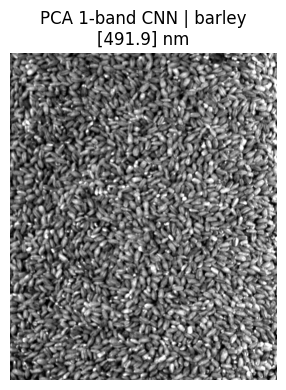

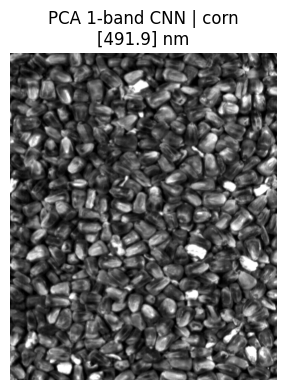

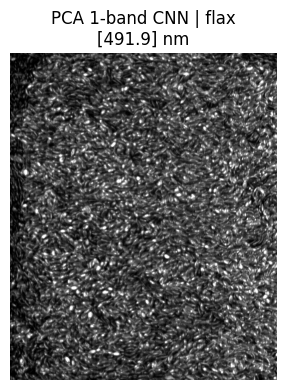


 VIP 1-band CNN [497.2]


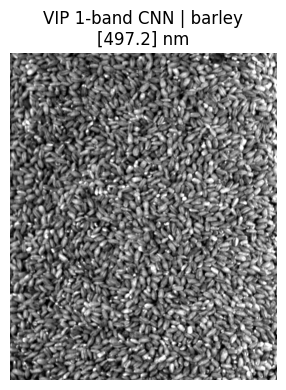

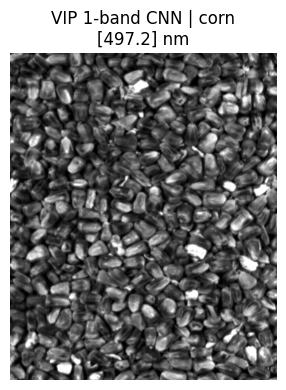

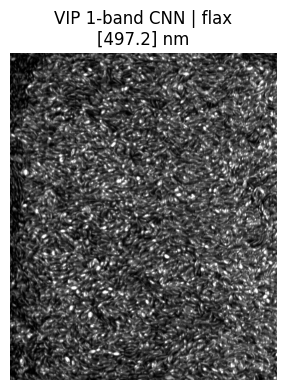


 PCA 3-band CNN [491.9, 611.9, 641.6]


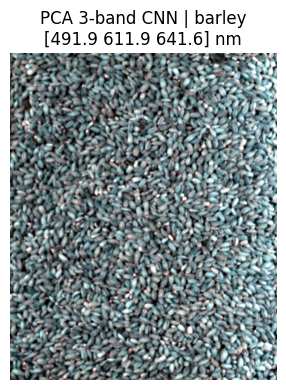

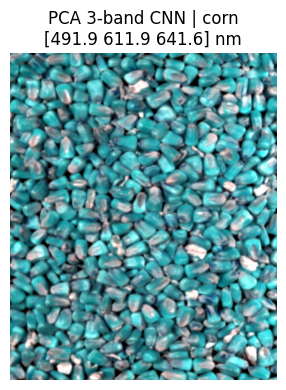

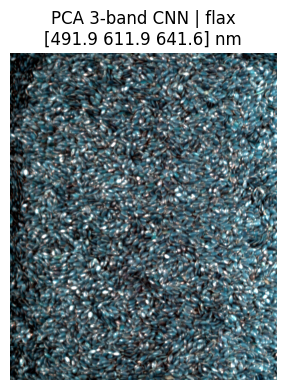


 VIP 3-band CNN [497.2, 609.2, 641.6]


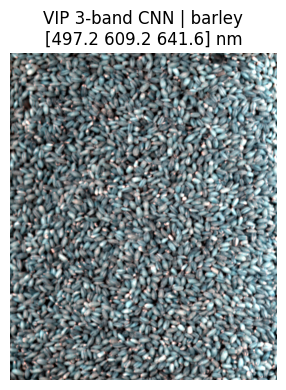

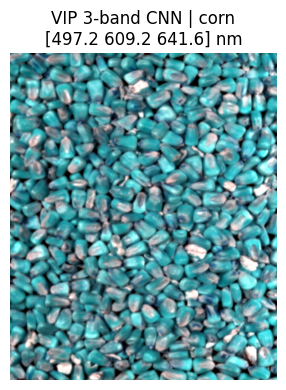

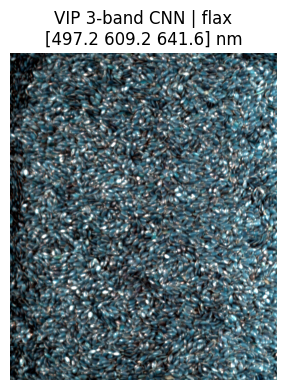


 RGB 3-band CNN [650.0, 530.0, 450.0]


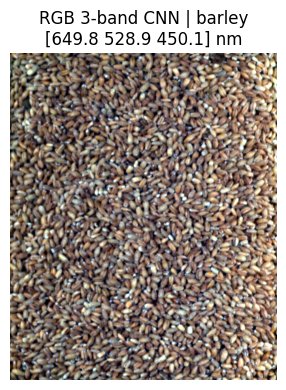

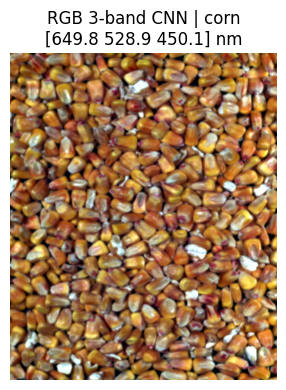

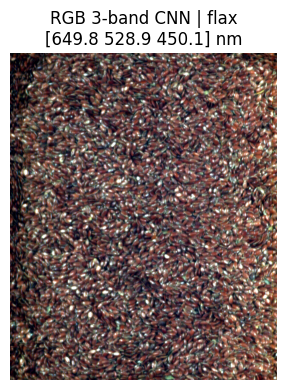

In [ ]:
# Preview PCA and VIP selected bands: as grayscale for 1-band subsets, as Pseudo-RGB for 3-band subsets 
def scale_channel_for_display(
    channel,
    lower_percentile=1,
    upper_percentile=99
):
    """
    Scale one channel independently to [0, 1] for display only
    """
    valid = channel[np.isfinite(channel)]

    low, high = np.percentile(
        valid,
        [lower_percentile, upper_percentile]
    )

    return np.clip(
        (channel - low) / (high - low + 1e-8),
        0.0,
        1.0
    )

for experiment_name, wavelengths in EXPERIMENTS.items():

    print("\n", experiment_name, wavelengths)

    for var in varieties:
        subset = train_files[
            train_files["variety"] == var
        ]

        if subset.empty:
            continue

        row = subset.iloc[0]

        img, mask, band_indices, actual_wlens = (
            load_multiband_image(
                row["filepath_FX10"],
                target_wavelengths=wavelengths,
                size=row["size"]
            )
        )

        plt.figure(figsize=(5, 4))

        if img.shape[-1] == 1:
            display_img = scale_channel_for_display(
                img[:, :, 0]
            )

            plt.imshow(
                display_img,
                cmap="gray"
            )

        else:
            display_img = np.stack(
                [
                    scale_channel_for_display(
                        img[:, :, channel_idx]
                    )
                    for channel_idx
                    in range(img.shape[-1])
                ],
                axis=-1
            )

            plt.imshow(display_img)

        plt.title(
            f"{experiment_name} | {var}\n"
            f"{np.round(actual_wlens, 1)} nm"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [ ]:
# Image tiling w/gaps
def make_spaced_tiles_multichannel(
    img,
    mask,
    n_rows=4,
    n_cols=4,
    tile_h=220,
    tile_w=180
):
    """Extract fixed-size tiles without resizing the image """

    H, W, C = img.shape

    required_h = n_rows * tile_h
    required_w = n_cols * tile_w

    if H < required_h or W < required_w:
        raise ValueError(
            f"Image shape {(H, W)} is too small for "
            f"{n_rows}x{n_cols} tiles of size {tile_h}x{tile_w}."
        )

    # Spread tile positions evenly across the image
    y_starts = np.linspace(
        0,
        H - tile_h,
        n_rows,
        dtype=int
    )

    x_starts = np.linspace(
        0,
        W - tile_w,
        n_cols,
        dtype=int
    )

    tiles = []
    foreground_fractions = []
    positions = []

    for r, y0 in enumerate(y_starts):
        for c, x0 in enumerate(x_starts):
            y1 = y0 + tile_h
            x1 = x0 + tile_w

            tile = img[y0:y1, x0:x1, :]
            tile_mask = mask[y0:y1, x0:x1]

            tiles.append(tile)
            foreground_fractions.append(float(tile_mask.mean()))
            positions.append((y0, y1, x0, x1))

    foreground_fractions = np.asarray(
        foreground_fractions,
        dtype=np.float32
    )

    assert len(tiles) == n_rows * n_cols
    assert all(tile.shape == (tile_h, tile_w, C) for tile in tiles)

    vertical_gaps = np.diff(y_starts) - tile_h
    horizontal_gaps = np.diff(x_starts) - tile_w

    return (
        tiles,
        foreground_fractions,
        positions,
        vertical_gaps,
        horizontal_gaps
    )

In [ ]:
# Represent each source image as a bag of tiles

class TiledMultibandHSIDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        target_wavelengths,
        channel_mean,
        channel_std,
        crop=True,
        input_mode="image",
        n_rows=4,
        n_cols=4,
        tile_h=220,
        tile_w=180
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.class_to_idx = class_to_idx

        self.target_wavelengths = list(
            target_wavelengths
        )

        self.channel_mean = np.asarray(
            channel_mean,
            dtype=np.float32
        ).reshape(
            1,
            1,
            -1
        )

        self.channel_std = np.asarray(
            channel_std,
            dtype=np.float32
        ).reshape(
            1,
            1,
            -1
        )

        if (
            self.channel_mean.shape[-1]
            != len(self.target_wavelengths)
        ):
            raise ValueError(
                "The channel mean does not match "
                "the selected wavelengths"
            )

        if (
            self.channel_std.shape[-1]
            != len(self.target_wavelengths)
        ):
            raise ValueError(
                "The channel standard deviation does not "
                "match the selected wavelengths"
            )

        if np.any(
            self.channel_std <= 0
        ):
            raise ValueError(
                "All channel standard deviations must be positive"
            )

        self.crop = crop
        self.input_mode = input_mode

        valid_input_modes = {
            "image",
            "foreground_only",
            "background_only",
            "mask_only"
        }

        if (
            self.input_mode
            not in valid_input_modes
        ):
            raise ValueError(
                f"Unknown input mode: "
                f"{self.input_mode}"
            )

        self.n_rows = int(n_rows)
        self.n_cols = int(n_cols)
        self.tile_h = int(tile_h)
        self.tile_w = int(tile_w)

        self.image_cache = {}

    def __len__(self):
        return len(self.df)

    def _apply_input_control(
        self,
        image,
        mask
    ):
        """Normalise the complete image"""

        image = image.astype(
            np.float32,
            copy=True
        )

        image = (
            image
            - self.channel_mean
        ) / self.channel_std

        return np.nan_to_num(
            image,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).astype(np.float32)

    def _load_image_bag(
        self,
        image_index
    ):
        row = self.df.iloc[
            image_index
        ]

        (
            image,
            mask,
            band_indices,
            actual_wavelengths
        ) = load_multiband_image(
            row["filepath_FX10"],
            target_wavelengths=(
                self.target_wavelengths
            ),
            crop=self.crop,
            size=row["size"]
        )

        image = self._apply_input_control(
            image,
            mask
        )

        (
            tiles,
            foreground_fractions,
            positions,
            vertical_gaps,
            horizontal_gaps
        ) = make_spaced_tiles_multichannel(
            image,
            mask,
            n_rows=self.n_rows,
            n_cols=self.n_cols,
            tile_h=self.tile_h,
            tile_w=self.tile_w
        )

        bag_tensor = torch.stack(
            [
                torch.from_numpy(
                    np.ascontiguousarray(
                        tile.transpose(
                            2,
                            0,
                            1
                        )
                    )
                ).float()
                for tile in tiles
            ],
            dim=0
        )

        label = int(
            self.class_to_idx[
                row["variety"]
            ]
        )

        self.image_cache[
            image_index
        ] = {
            "bag": bag_tensor,
            "label": label,
            "foreground_fractions": (
                torch.tensor(
                    foreground_fractions,
                    dtype=torch.float32
                )
            ),
            "positions": positions,
            "vertical_gaps": vertical_gaps,
            "horizontal_gaps": horizontal_gaps,
            "band_indices": band_indices,
            "actual_wavelengths": (
                actual_wavelengths
            )
        }

    def preload(self):
        for image_index in range(
            len(self)
        ):
            if (
                image_index
                not in self.image_cache
            ):
                self._load_image_bag(
                    image_index
                )

    def __getitem__(
        self,
        image_index
    ):
        if (
            image_index
            not in self.image_cache
        ):
            self._load_image_bag(
                image_index
            )

        cached = self.image_cache[
            image_index
        ]

        return (
            cached["bag"],
            cached["label"],
            image_index,
            cached[
                "foreground_fractions"
            ]
        )

In [ ]:
# Create image-level datasets and batches

N_ROWS = 4
N_COLS = 4

TILE_HEIGHT = 220
TILE_WIDTH = 180

TILES_PER_IMAGE = (
    N_ROWS
    * N_COLS
)

IMAGES_PER_BATCH = 2


train_files_run = (
    train_files
    .reset_index(drop=True)
    .copy()
)

valid_files_run = (
    valid_files
    .reset_index(drop=True)
    .copy()
)

test_files_run = (
    test_files
    .reset_index(drop=True)
    .copy()
)


def resolved_path_set(
    dataframe
):
    """Return resolved image paths"""

    return {
        str(
            Path(filepath).resolve()
        )
        for filepath
        in dataframe["filepath_FX10"]
    }


train_paths = resolved_path_set(
    train_files_run
)

valid_paths = resolved_path_set(
    valid_files_run
)

test_paths = resolved_path_set(
    test_files_run
)


assert train_paths.isdisjoint(
    valid_paths
)

assert train_paths.isdisjoint(
    test_paths
)

assert valid_paths.isdisjoint(
    test_paths
)


def calculate_training_channel_stats(
    dataframe,
    target_wavelengths
):
    """Calculate channel statistics from training images only"""

    channel_sum = np.zeros(
        len(target_wavelengths),
        dtype=np.float64
    )

    channel_squared_sum = np.zeros(
        len(target_wavelengths),
        dtype=np.float64
    )

    pixel_count = 0

    for _, row in dataframe.iterrows():
        image, mask, _, _ = (
            load_multiband_image(
                row["filepath_FX10"],
                target_wavelengths=(
                    target_wavelengths
                ),
                size=row["size"]
            )
        )

        valid_pixels = image.reshape(
            -1,
            image.shape[-1]
        )

        valid_pixels = valid_pixels[
            np.isfinite(
                valid_pixels
            ).all(axis=1)
        ]

        if valid_pixels.size == 0:
            continue

        channel_sum += (
            valid_pixels.sum(
                axis=0,
                dtype=np.float64
            )
        )

        channel_squared_sum += (
            np.square(
                valid_pixels,
                dtype=np.float64
            ).sum(
                axis=0,
                dtype=np.float64
            )
        )

        pixel_count += (
            valid_pixels.shape[0]
        )

    if pixel_count == 0:
        raise RuntimeError(
            "No valid training pixels were found"
        )

    channel_mean = (
        channel_sum
        / pixel_count
    )

    channel_variance = (
        channel_squared_sum
        / pixel_count
        - np.square(
            channel_mean
        )
    )

    channel_std = np.sqrt(
        np.maximum(
            channel_variance,
            1e-12
        )
    )

    return (
        channel_mean.astype(
            np.float32
        ),
        channel_std.astype(
            np.float32
        )
    )


def seed_dataloader_worker(
    worker_id
):
    worker_seed = (
        torch.initial_seed()
        % (2**32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


def make_datasets(
    target_wavelengths,
    channel_mean,
    channel_std,
    include_test=False,
    preload=True,
    input_mode="image"
):
    datasets = {
        "train": TiledMultibandHSIDataset(
            train_files_run,
            class_to_idx,
            target_wavelengths,
            channel_mean,
            channel_std,
            input_mode=input_mode,
            n_rows=N_ROWS,
            n_cols=N_COLS,
            tile_h=TILE_HEIGHT,
            tile_w=TILE_WIDTH
        ),
        "valid": TiledMultibandHSIDataset(
            valid_files_run,
            class_to_idx,
            target_wavelengths,
            channel_mean,
            channel_std,
            input_mode=input_mode,
            n_rows=N_ROWS,
            n_cols=N_COLS,
            tile_h=TILE_HEIGHT,
            tile_w=TILE_WIDTH
        )
    }

    if include_test:
        datasets[
            "test"
        ] = TiledMultibandHSIDataset(
            test_files_run,
            class_to_idx,
            target_wavelengths,
            channel_mean,
            channel_std,
            input_mode=input_mode,
            n_rows=N_ROWS,
            n_cols=N_COLS,
            tile_h=TILE_HEIGHT,
            tile_w=TILE_WIDTH
        )

    if preload:
        for (
            split_name,
            dataset
        ) in datasets.items():
            print(
                f"Preloading {split_name} "
                f"images for "
                f"{list(target_wavelengths)}"
            )

            dataset.preload()

    return datasets


def make_loaders(
    datasets,
    image_batch_size=IMAGES_PER_BATCH,
    seed=SEED
):
    generator = torch.Generator()

    generator.manual_seed(
        seed
    )

    common_arguments = {
        "batch_size": image_batch_size,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "worker_init_fn": (
            seed_dataloader_worker
        ),
        "persistent_workers": False
    }

    train_loader = DataLoader(
        datasets["train"],
        shuffle=True,
        generator=generator,
        **common_arguments
    )

    train_eval_loader = DataLoader(
        datasets["train"],
        shuffle=False,
        **common_arguments
    )

    valid_loader = DataLoader(
        datasets["valid"],
        shuffle=False,
        **common_arguments
    )

    test_loader = None

    if "test" in datasets:
        test_loader = DataLoader(
            datasets["test"],
            shuffle=False,
            **common_arguments
        )

    return (
        train_loader,
        train_eval_loader,
        valid_loader,
        test_loader
    )


ORDINARY IMAGE-LEVEL SPLIT
Training images: 27
Validation images: 9
Test images: 9

Training images by class and size:


size,l,m,s
variety,,,
barley,3,3,3
corn,3,3,3
flax,3,3,3


Validation images by class and size:


size,l,m,s
variety,,,
barley,1,1,1
corn,1,1,1
flax,1,1,1


Test images by class and size:


size,l,m,s
variety,,,
barley,1,1,1
corn,1,1,1
flax,1,1,1


In [ ]:
# Define the pretrained ResNet18 tile classifier

USE_IMAGENET_WEIGHTS = True


def adapt_resnet18_input_layer(
    backbone,
    num_channels,
    pretrained
):
    """Adapt ResNet18 for one or three channels"""

    if num_channels not in {1, 3}:
        raise ValueError(
            "ResNet18 requires one or three input channels"
        )

    if num_channels == 3:
        return backbone

    original_layer = backbone.conv1

    replacement_layer = nn.Conv2d(
        in_channels=1,
        out_channels=original_layer.out_channels,
        kernel_size=original_layer.kernel_size,
        stride=original_layer.stride,
        padding=original_layer.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            replacement_layer.weight.copy_(
                original_layer.weight.mean(
                    dim=1,
                    keepdim=True
                )
            )

        else:
            nn.init.kaiming_normal_(
                replacement_layer.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    backbone.conv1 = replacement_layer

    return backbone


class ResNet18TileClassifier(nn.Module):
    """Classify every tile using the same ResNet18"""

    def __init__(
        self,
        num_channels,
        num_classes,
        dropout=0.30,
        use_imagenet_weights=True
    ):
        super().__init__()

        self.num_channels = int(
            num_channels
        )

        self.num_classes = int(
            num_classes
        )

        weights = (
            ResNet18_Weights.DEFAULT
            if use_imagenet_weights
            else None
        )

        backbone = resnet18(
            weights=weights
        )

        backbone = adapt_resnet18_input_layer(
            backbone,
            num_channels=self.num_channels,
            pretrained=use_imagenet_weights
        )

        self.feature_dimension = int(
            backbone.fc.in_features
        )

        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(
                p=float(dropout)
            ),
            nn.Linear(
                self.feature_dimension,
                self.num_classes
            )
        )

        self.set_training_stage(
            "head"
        )

    def freeze_batch_norm(self):
        """Freeze BatchNorm statistics and parameters"""

        for module in self.backbone.modules():
            if isinstance(
                module,
                nn.BatchNorm2d
            ):
                module.eval()

                for parameter in module.parameters():
                    parameter.requires_grad = False

    def set_training_stage(
        self,
        stage
    ):
        """Select the trainable ResNet18 layers"""

        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        if stage == "head":
            pass

        elif stage == "layer4":
            for parameter in (
                self.backbone
                .layer4
                .parameters()
            ):
                parameter.requires_grad = True

        else:
            raise ValueError(
                f"Unknown training stage: {stage}"
            )

        for parameter in self.classifier.parameters():
            parameter.requires_grad = True

        self.freeze_batch_norm()

    def train(
        self,
        mode=True
    ):
        super().train(mode)

        self.freeze_batch_norm()

        return self

    def forward(
        self,
        bags
    ):
        if bags.ndim != 5:
            raise ValueError(
                "Expected bags shaped "
                "[batch tiles channels height width]"
            )

        (
            batch_size,
            n_tiles,
            channels,
            height,
            width
        ) = bags.shape

        if channels != self.num_channels:
            raise ValueError(
                f"Expected {self.num_channels} channels "
                f"but received {channels}"
            )

        flat_tiles = bags.reshape(
            batch_size * n_tiles,
            channels,
            height,
            width
        )

        flat_features = self.backbone(
            flat_tiles
        )

        flat_tile_logits = self.classifier(
            flat_features
        )

        tile_logits = flat_tile_logits.reshape(
            batch_size,
            n_tiles,
            self.num_classes
        )

        return {
            "tile_logits": tile_logits
        }


def build_resnet18_tile_classifier(
    num_channels,
    num_classes=3,
    dropout=0.30
):
    """Build the ResNet18 tile classifier"""

    return ResNet18TileClassifier(
        num_channels=num_channels,
        num_classes=num_classes,
        dropout=dropout,
        use_imagenet_weights=(
            USE_IMAGENET_WEIGHTS
        )
    )


probe_model = (
    build_resnet18_tile_classifier(
        num_channels=1,
        num_classes=len(varieties)
    )
)


print(
    "Architecture: ImageNet-pretrained "
    "ResNet18 tile classifier"
)

print(
    "Trainable parameters at initialisation:",
    sum(
        parameter.numel()
        for parameter
        in probe_model.parameters()
        if parameter.requires_grad
    )
)


del probe_model

Architecture: genuine torchvision ResNet18
ImageNet pretrained weights: True
Trainable parameters: 11171779
Total parameters: 11171779


In [ ]:
# Define tile training and image voting functions

def make_safe_name(text):
    """Create a filename safe name"""

    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def aggregate_tile_predictions(
    tile_logits
):
    """Combine tile predictions using majority voting"""

    tile_probabilities = torch.softmax(
        tile_logits,
        dim=2
    )

    tile_predictions = tile_probabilities.argmax(
        dim=2
    )

    batch_size = tile_logits.shape[0]
    num_classes = tile_logits.shape[2]

    image_predictions = []
    image_probabilities = []

    for image_index in range(
        batch_size
    ):
        votes = torch.bincount(
            tile_predictions[
                image_index
            ],
            minlength=num_classes
        )

        maximum_votes = votes.max()

        tied_classes = torch.where(
            votes == maximum_votes
        )[0]

        mean_probabilities = (
            tile_probabilities[
                image_index
            ]
            .mean(dim=0)
        )

        if len(tied_classes) == 1:
            image_prediction = (
                tied_classes[0]
            )

        else:
            tied_probabilities = (
                mean_probabilities[
                    tied_classes
                ]
            )

            image_prediction = (
                tied_classes[
                    tied_probabilities.argmax()
                ]
            )

        image_predictions.append(
            image_prediction
        )

        image_probabilities.append(
            mean_probabilities
        )

    return {
        "tile_probabilities": (
            tile_probabilities
        ),
        "tile_predictions": (
            tile_predictions
        ),
        "image_probabilities": (
            torch.stack(
                image_probabilities
            )
        ),
        "image_predictions": (
            torch.stack(
                image_predictions
            )
        )
    }


def calculate_tile_loss(
    tile_logits,
    labels,
    loss_function
):
    """Calculate one loss for every tile"""

    batch_size = tile_logits.shape[0]
    n_tiles = tile_logits.shape[1]
    n_classes = tile_logits.shape[2]

    repeated_labels = (
        labels[:, None]
        .expand(
            -1,
            n_tiles
        )
    )

    loss = loss_function(
        tile_logits.reshape(
            batch_size * n_tiles,
            n_classes
        ),
        repeated_labels.reshape(
            batch_size * n_tiles
        )
    )

    return loss


def build_optimizer(
    model,
    head_learning_rate,
    weight_decay
):
    """Create the classifier-head optimiser"""

    return torch.optim.AdamW(
        model.classifier.parameters(),
        lr=head_learning_rate,
        weight_decay=weight_decay
    )


def run_tile_epoch(
    model,
    loader,
    loss_function,
    optimizer=None
):
    """Run one tile training or evaluation epoch"""

    training = optimizer is not None

    if training:
        model.train()

    else:
        model.eval()

    total_loss = 0.0
    total_tiles = 0

    tile_targets = []
    tile_predictions = []

    image_targets = []
    image_predictions = []

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:
        for (
            bags,
            labels,
            image_indices,
            foreground_fractions
        ) in loader:

            bags = bags.to(
                device,
                non_blocking=PIN_MEMORY
            )

            labels = labels.to(
                device,
                non_blocking=PIN_MEMORY
            )

            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )

            outputs = model(
                bags
            )

            tile_logits = outputs[
                "tile_logits"
            ]

            loss = calculate_tile_loss(
                tile_logits,
                labels,
                loss_function
            )

            if training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0
                )

                optimizer.step()

            aggregation = (
                aggregate_tile_predictions(
                    tile_logits
                )
            )

            current_tile_predictions = (
                aggregation[
                    "tile_predictions"
                ]
            )

            current_image_predictions = (
                aggregation[
                    "image_predictions"
                ]
            )

            repeated_labels = (
                labels[:, None]
                .expand(
                    -1,
                    tile_logits.shape[1]
                )
            )

            n_batch_tiles = (
                labels.shape[0]
                * tile_logits.shape[1]
            )

            total_loss += (
                float(loss.item())
                * n_batch_tiles
            )

            total_tiles += (
                n_batch_tiles
            )

            tile_targets.extend(
                repeated_labels.detach()
                .cpu()
                .reshape(-1)
                .tolist()
            )

            tile_predictions.extend(
                current_tile_predictions.detach()
                .cpu()
                .reshape(-1)
                .tolist()
            )

            image_targets.extend(
                labels.detach()
                .cpu()
                .tolist()
            )

            image_predictions.extend(
                current_image_predictions.detach()
                .cpu()
                .tolist()
            )

    return {
        "loss": (
            total_loss
            / max(
                total_tiles,
                1
            )
        ),
        "tile_accuracy": (
            accuracy_score(
                tile_targets,
                tile_predictions
            )
        ),
        "tile_balanced_accuracy": (
            balanced_accuracy_score(
                tile_targets,
                tile_predictions
            )
        ),
        "tile_macro_f1": (
            f1_score(
                tile_targets,
                tile_predictions,
                average="macro",
                zero_division=0
            )
        ),
        "image_accuracy": (
            accuracy_score(
                image_targets,
                image_predictions
            )
        ),
        "image_balanced_accuracy": (
            balanced_accuracy_score(
                image_targets,
                image_predictions
            )
        ),
        "image_macro_f1": (
            f1_score(
                image_targets,
                image_predictions,
                average="macro",
                zero_division=0
            )
        )
    }


def predict_tile_vote(
    model,
    loader,
    dataframe
):
    """Generate tile and majority vote predictions"""

    model.eval()

    image_records = []
    tile_records = []

    with torch.no_grad():
        for (
            bags,
            labels,
            image_indices,
            foreground_fractions
        ) in loader:

            bags = bags.to(
                device,
                non_blocking=PIN_MEMORY
            )

            outputs = model(
                bags
            )

            tile_logits = outputs[
                "tile_logits"
            ]

            aggregation = (
                aggregate_tile_predictions(
                    tile_logits
                )
            )

            tile_probabilities = (
                aggregation[
                    "tile_probabilities"
                ]
                .cpu()
            )

            tile_predictions = (
                aggregation[
                    "tile_predictions"
                ]
                .cpu()
            )

            image_probabilities = (
                aggregation[
                    "image_probabilities"
                ]
                .cpu()
            )

            image_predictions = (
                aggregation[
                    "image_predictions"
                ]
                .cpu()
            )

            for batch_position in range(
                len(labels)
            ):
                image_index = int(
                    image_indices[
                        batch_position
                    ]
                )

                row = dataframe.iloc[
                    image_index
                ]

                true_class = int(
                    labels[
                        batch_position
                    ]
                )

                predicted_class = int(
                    image_predictions[
                        batch_position
                    ]
                )

                tile_votes = torch.bincount(
                    tile_predictions[
                        batch_position
                    ],
                    minlength=len(varieties)
                )

                image_record = {
                    "sample_name": (
                        row["sample_name"]
                    ),
                    "variety": (
                        row["variety"]
                    ),
                    "size": row["size"],
                    "rep": row["rep"],
                    "true_class": (
                        true_class
                    ),
                    "predicted_class": (
                        predicted_class
                    ),
                    "correct": (
                        true_class
                        == predicted_class
                    ),
                    "maximum_probability": float(
                        image_probabilities[
                            batch_position
                        ].max()
                    )
                }

                for (
                    class_index,
                    class_name
                ) in idx_to_class.items():
                    image_record[
                        f"votes_{class_name}"
                    ] = int(
                        tile_votes[
                            class_index
                        ]
                    )

                    image_record[
                        f"mean_probability_{class_name}"
                    ] = float(
                        image_probabilities[
                            batch_position,
                            class_index
                        ]
                    )

                image_records.append(
                    image_record
                )

                for tile_index in range(
                    tile_predictions.shape[1]
                ):
                    tile_record = {
                        "sample_name": (
                            row["sample_name"]
                        ),
                        "tile_index": (
                            tile_index
                        ),
                        "true_class": (
                            true_class
                        ),
                        "predicted_class": int(
                            tile_predictions[
                                batch_position,
                                tile_index
                            ]
                        ),
                        "correct": (
                            true_class
                            == int(
                                tile_predictions[
                                    batch_position,
                                    tile_index
                                ]
                            )
                        )
                    }

                    for (
                        class_index,
                        class_name
                    ) in idx_to_class.items():
                        tile_record[
                            f"probability_{class_name}"
                        ] = float(
                            tile_probabilities[
                                batch_position,
                                tile_index,
                                class_index
                            ]
                        )

                    tile_records.append(
                        tile_record
                    )

    return (
        pd.DataFrame(
            image_records
        ),
        pd.DataFrame(
            tile_records
        )
    )


def train_resnet18_tile_model(
    experiment_name,
    target_wavelengths,
    train_loader,
    train_eval_loader,
    valid_loader,
    head_learning_rate,
    weight_decay,
    dropout,
    label_smoothing,
    max_epochs,
    patience,
    run_seed
):
    """Train one frozen-backbone ResNet18 tile classifier"""

    seed_everything(
        run_seed
    )

    model = (
        build_resnet18_tile_classifier(
            num_channels=len(
                target_wavelengths
            ),
            num_classes=len(varieties),
            dropout=dropout
        )
        .to(device)
    )

    # Keep the pretrained feature extractor frozen

    model.set_training_stage(
        "head"
    )

    optimizer = build_optimizer(
        model=model,
        head_learning_rate=(
            head_learning_rate
        ),
        weight_decay=weight_decay
    )

    loss_function = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing
    )

    best_state = None
    best_epoch = 0
    best_valid_loss = np.inf

    epochs_without_improvement = 0

    history = []

    for epoch in range(
        1,
        max_epochs + 1
    ):
        optimisation_metrics = (
            run_tile_epoch(
                model,
                train_loader,
                loss_function,
                optimizer=optimizer
            )
        )

        train_metrics = (
            run_tile_epoch(
                model,
                train_eval_loader,
                loss_function
            )
        )

        valid_metrics = (
            run_tile_epoch(
                model,
                valid_loader,
                loss_function
            )
        )

        history.append({
            "epoch": epoch,
            "stage": (
                "frozen_backbone"
            ),
            "optimisation_tile_loss": (
                optimisation_metrics[
                    "loss"
                ]
            ),
            "train_tile_loss": (
                train_metrics[
                    "loss"
                ]
            ),
            "train_tile_accuracy": (
                train_metrics[
                    "tile_accuracy"
                ]
            ),
            "train_image_accuracy": (
                train_metrics[
                    "image_accuracy"
                ]
            ),
            "valid_tile_loss": (
                valid_metrics[
                    "loss"
                ]
            ),
            "valid_tile_accuracy": (
                valid_metrics[
                    "tile_accuracy"
                ]
            ),
            "valid_tile_balanced_accuracy": (
                valid_metrics[
                    "tile_balanced_accuracy"
                ]
            ),
            "valid_tile_macro_f1": (
                valid_metrics[
                    "tile_macro_f1"
                ]
            ),
            "valid_image_accuracy": (
                valid_metrics[
                    "image_accuracy"
                ]
            ),
            "valid_image_balanced_accuracy": (
                valid_metrics[
                    "image_balanced_accuracy"
                ]
            ),
            "valid_image_macro_f1": (
                valid_metrics[
                    "image_macro_f1"
                ]
            )
        })

        print(
            f"{experiment_name} | "
            f"epoch {epoch:03d} | "
            f"train loss="
            f"{train_metrics['loss']:.4f} | "
            f"train tile acc="
            f"{train_metrics['tile_accuracy']:.3f} | "
            f"train image acc="
            f"{train_metrics['image_accuracy']:.3f} | "
            f"valid loss="
            f"{valid_metrics['loss']:.4f} | "
            f"valid tile acc="
            f"{valid_metrics['tile_accuracy']:.3f} | "
            f"valid image acc="
            f"{valid_metrics['image_accuracy']:.3f}"
        )

        if (
            valid_metrics["loss"]
            < best_valid_loss - 1e-4
        ):
            best_valid_loss = (
                valid_metrics[
                    "loss"
                ]
            )

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= patience
        ):
            print(
                "Early stopping at epoch",
                epoch
            )

            break

    if best_state is None:
        raise RuntimeError(
            "No model checkpoint was selected"
        )

    model.load_state_dict(
        best_state
    )

    final_train_metrics = (
        run_tile_epoch(
            model,
            train_eval_loader,
            loss_function
        )
    )

    final_valid_metrics = (
        run_tile_epoch(
            model,
            valid_loader,
            loss_function
        )
    )

    return {
        "model": model,
        "history": pd.DataFrame(
            history
        ),
        "best_epoch": (
            best_epoch
        ),
        "best_valid_loss": (
            best_valid_loss
        ),
        "final_train_metrics": (
            final_train_metrics
        ),
        "final_valid_metrics": (
            final_valid_metrics
        )
    } 

In [ ]:
# Define the tile classifier hyperparameter search

SPATIAL_CONTROL_MODE = "image"

MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10

FIXED_LABEL_SMOOTHING = 0.05


HYPERPARAMETER_GRID = {
    "head_learning_rate": [
        3e-5,
        1e-4,
        3e-4,
        1e-3
    ],
    "weight_decay": [
        1e-4,
        1e-3,
        1e-2
    ],
    "dropout": [
        0.20,
        0.40
    ]
}


TUNING_CANDIDATES = [
    {
        "head_learning_rate": (
            head_learning_rate
        ),
        "weight_decay": (
            weight_decay
        ),
        "dropout": dropout
    }
    for (
        head_learning_rate,
        weight_decay,
        dropout
    ) in product(
        HYPERPARAMETER_GRID[
            "head_learning_rate"
        ],
        HYPERPARAMETER_GRID[
            "weight_decay"
        ],
        HYPERPARAMETER_GRID[
            "dropout"
        ]
    )
]


search_configuration = {
    "input_mode": (
        SPATIAL_CONTROL_MODE
    ),
    "standardisation": (
        "training_channel_mean_and_std"
    ),
    "label_smoothing": (
        FIXED_LABEL_SMOOTHING
    ),
    "transfer_learning": (
        "frozen_imagenet_backbone"
    ),
    "trainable_parameters": (
        "classifier_head_only"
    ),
    "max_epochs": (
        MAX_EPOCHS
    ),
    "patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "loss_level": (
        "tile"
    ),
    "aggregation": (
        "majority_vote"
    ),
    "tie_break": (
        "mean_class_probability"
    ),
    "tiles_per_image": (
        TILES_PER_IMAGE
    ),
    "selection_primary": (
        "validation_tile_loss"
    ),
    "selection_tiebreakers": [
        "validation_image_balanced_accuracy",
        "validation_image_macro_f1",
        "earlier_best_epoch"
    ],
    "n_candidates": len(
        TUNING_CANDIDATES
    )
}


with open(
    RESULTS_DIR
    / "resnet18_search_configuration.json",
    "w"
) as file:
    json.dump(
        search_configuration,
        file,
        indent=2
    )


print(
    "Input mode:",
    SPATIAL_CONTROL_MODE
)

print(
    "Tiles per image:",
    TILES_PER_IMAGE
)

print(
    "Transfer learning:",
    "frozen ImageNet backbone"
)

print(
    "Candidates per model:",
    len(
        TUNING_CANDIDATES
    )
)


display(
    pd.DataFrame(
        TUNING_CANDIDATES
    )
)

Final spatial input: foreground_only
Maximum epochs per run: 120
Early-stopping patience: 15
Number of final models: 5
Candidates per model: 12
Total tuning runs: 60
Final retraining runs: 5
Total training runs: 65


,head_learning_rate,weight_decay,dropout
0,0.00003,0.0001,0.3
1,0.00003,0.0001,0.5
2,0.00003,0.0010,0.3
3,0.00003,0.0010,0.5
4,0.00005,0.0001,0.3
5,0.00005,0.0001,0.5
6,0.00005,0.0010,0.3
7,0.00005,0.0010,0.5
8,0.00010,0.0001,0.3
9,0.00010,0.0001,0.5


In [ ]:
# Tune each model and retrain it using the selected settings

TUNING_DIR = (
    RESULTS_DIR
    / "tuning"
)

FINAL_MODEL_DIR = (
    RESULTS_DIR
    / "final_models"
)


TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


all_tuning_records = []
selected_configurations = {}
all_spatial_results = {}


for (
    experiment_name,
    target_wavelengths
) in EXPERIMENTS.items():

    print(
        "\n"
        + "=" * 90
    )

    print(
        "Tuning:",
        experiment_name
    )

    print(
        "=" * 90
    )

    (
        channel_mean,
        channel_std
    ) = calculate_training_channel_stats(
        train_files_run,
        target_wavelengths
    )

    datasets = make_datasets(
        target_wavelengths=(
            target_wavelengths
        ),
        channel_mean=channel_mean,
        channel_std=channel_std,
        include_test=False,
        preload=True,
        input_mode=(
            SPATIAL_CONTROL_MODE
        )
    )

    for (
        candidate_index,
        candidate
    ) in enumerate(
        TUNING_CANDIDATES,
        start=1
    ):

        print(
            f"\nCandidate "
            f"{candidate_index}/"
            f"{len(TUNING_CANDIDATES)}"
        )

        print(candidate)

        (
            train_loader,
            train_eval_loader,
            valid_loader,
            _
        ) = make_loaders(
            datasets,
            image_batch_size=(
                IMAGES_PER_BATCH
            ),
            seed=SEED
        )

        tuning_result = (
            train_resnet18_tile_model(
                experiment_name=(
                    experiment_name
                ),
                target_wavelengths=(
                    target_wavelengths
                ),
                train_loader=(
                    train_loader
                ),
                train_eval_loader=(
                    train_eval_loader
                ),
                valid_loader=(
                    valid_loader
                ),
                head_learning_rate=(
                    candidate[
                        "head_learning_rate"
                    ]
                ),
                weight_decay=(
                    candidate[
                        "weight_decay"
                    ]
                ),
                dropout=(
                    candidate[
                        "dropout"
                    ]
                ),
                label_smoothing=(
                    FIXED_LABEL_SMOOTHING
                ),
                max_epochs=(
                    MAX_EPOCHS
                ),
                patience=(
                    EARLY_STOPPING_PATIENCE
                ),
                run_seed=SEED
            )
        )

        valid_metrics = (
            tuning_result[
                "final_valid_metrics"
            ]
        )

        tuning_record = {
            "experiment": (
                experiment_name
            ),
            "candidate": (
                candidate_index
            ),
            "head_learning_rate": (
                candidate[
                    "head_learning_rate"
                ]
            ),
            "weight_decay": (
                candidate[
                    "weight_decay"
                ]
            ),
            "dropout": (
                candidate[
                    "dropout"
                ]
            ),
            "label_smoothing": (
                FIXED_LABEL_SMOOTHING
            ),
            "best_epoch": (
                tuning_result[
                    "best_epoch"
                ]
            ),
            "best_valid_tile_loss": (
                tuning_result[
                    "best_valid_loss"
                ]
            ),
            "valid_tile_accuracy": (
                valid_metrics[
                    "tile_accuracy"
                ]
            ),
            "valid_tile_balanced_accuracy": (
                valid_metrics[
                    "tile_balanced_accuracy"
                ]
            ),
            "valid_tile_macro_f1": (
                valid_metrics[
                    "tile_macro_f1"
                ]
            ),
            "valid_image_accuracy": (
                valid_metrics[
                    "image_accuracy"
                ]
            ),
            "valid_image_balanced_accuracy": (
                valid_metrics[
                    "image_balanced_accuracy"
                ]
            ),
            "valid_image_macro_f1": (
                valid_metrics[
                    "image_macro_f1"
                ]
            )
        }

        all_tuning_records.append(
            tuning_record
        )

        pd.DataFrame(
            all_tuning_records
        ).to_csv(
            TUNING_DIR
            / "resnet18_tile_tuning_results.csv",
            index=False
        )

        del tuning_result
        del train_loader
        del train_eval_loader
        del valid_loader

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del datasets

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


tuning_results_df = pd.DataFrame(
    all_tuning_records
)


for (
    experiment_name,
    group
) in tuning_results_df.groupby(
    "experiment"
):

    best_row = group.sort_values(
        by=[
            "best_valid_tile_loss",
            "valid_image_balanced_accuracy",
            "valid_image_macro_f1",
            "best_epoch"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    ).iloc[0]

    selected_configurations[
        experiment_name
    ] = {
        "head_learning_rate": float(
            best_row[
                "head_learning_rate"
            ]
        ),
        "weight_decay": float(
            best_row[
                "weight_decay"
            ]
        ),
        "dropout": float(
            best_row[
                "dropout"
            ]
        )
    }


selected_configurations_df = (
    pd.DataFrame(
        selected_configurations
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "experiment"
        }
    )
)


selected_configurations_df.to_csv(
    TUNING_DIR
    / "selected_resnet18_tile_configurations.csv",
    index=False
)


display(
    selected_configurations_df
)


for (
    experiment_name,
    target_wavelengths
) in EXPERIMENTS.items():

    print(
        "\n"
        + "=" * 90
    )

    print(
        "Final training:",
        experiment_name
    )

    print(
        "=" * 90
    )

    selected = (
        selected_configurations[
            experiment_name
        ]
    )

    (
        channel_mean,
        channel_std
    ) = calculate_training_channel_stats(
        train_files_run,
        target_wavelengths
    )

    datasets = make_datasets(
        target_wavelengths=(
            target_wavelengths
        ),
        channel_mean=channel_mean,
        channel_std=channel_std,
        include_test=False,
        preload=True,
        input_mode=(
            SPATIAL_CONTROL_MODE
        )
    )

    (
        train_loader,
        train_eval_loader,
        valid_loader,
        _
    ) = make_loaders(
        datasets,
        image_batch_size=(
            IMAGES_PER_BATCH
        ),
        seed=SEED
    )

    result = (
        train_resnet18_tile_model(
            experiment_name=(
                experiment_name
            ),
            target_wavelengths=(
                target_wavelengths
            ),
            train_loader=(
                train_loader
            ),
            train_eval_loader=(
                train_eval_loader
            ),
            valid_loader=(
                valid_loader
            ),
            head_learning_rate=(
                selected[
                    "head_learning_rate"
                ]
            ),
            weight_decay=(
                selected[
                    "weight_decay"
                ]
            ),
            dropout=(
                selected[
                    "dropout"
                ]
            ),
            label_smoothing=(
                FIXED_LABEL_SMOOTHING
            ),
            max_epochs=(
                MAX_EPOCHS
            ),
            patience=(
                EARLY_STOPPING_PATIENCE
            ),
            run_seed=SEED
        )
    )

    (
        validation_image_df,
        validation_tile_df
    ) = predict_tile_vote(
        result["model"],
        valid_loader,
        valid_files_run
    )

    valid_image_accuracy = (
        accuracy_score(
            validation_image_df[
                "true_class"
            ],
            validation_image_df[
                "predicted_class"
            ]
        )
    )

    valid_image_balanced_accuracy = (
        balanced_accuracy_score(
            validation_image_df[
                "true_class"
            ],
            validation_image_df[
                "predicted_class"
            ]
        )
    )

    valid_image_macro_f1 = (
        f1_score(
            validation_image_df[
                "true_class"
            ],
            validation_image_df[
                "predicted_class"
            ],
            average="macro",
            zero_division=0
        )
    )

    valid_tile_accuracy = (
        accuracy_score(
            validation_tile_df[
                "true_class"
            ],
            validation_tile_df[
                "predicted_class"
            ]
        )
    )

    result.update({
        "target_wavelengths": list(
            target_wavelengths
        ),
        "channel_mean": (
            channel_mean.tolist()
        ),
        "channel_std": (
            channel_std.tolist()
        ),
        "head_learning_rate": (
            selected[
                "head_learning_rate"
            ]
        ),
        "weight_decay": (
            selected[
                "weight_decay"
            ]
        ),
        "dropout": (
            selected[
                "dropout"
            ]
        ),
        "label_smoothing": (
            FIXED_LABEL_SMOOTHING
        ),
        "seed": SEED,
        "final_valid_image_records": (
            validation_image_df
        ),
        "final_valid_tile_records": (
            validation_tile_df
        ),
        "valid_image_accuracy": (
            valid_image_accuracy
        ),
        "valid_image_balanced_accuracy": (
            valid_image_balanced_accuracy
        ),
        "valid_image_macro_f1": (
            valid_image_macro_f1
        ),
        "valid_tile_accuracy": (
            valid_tile_accuracy
        ),
        "aggregation": (
            "majority_vote"
        )
    })

    safe_name = make_safe_name(
        experiment_name
    )

    torch.save(
        {
            "model_state_dict": (
                result[
                    "model"
                ].state_dict()
            ),
            "target_wavelengths": (
                result[
                    "target_wavelengths"
                ]
            ),
            "channel_mean": (
                result[
                    "channel_mean"
                ]
            ),
            "channel_std": (
                result[
                    "channel_std"
                ]
            ),
            "class_to_idx": (
                class_to_idx
            ),
            "selected_configuration": (
                selected
            ),
            "label_smoothing": (
                FIXED_LABEL_SMOOTHING
            ),
            "best_epoch": (
                result[
                    "best_epoch"
                ]
            ),
            "loss_level": (
                "tile"
            ),
            "aggregation": (
                "majority_vote"
            )
        },
        FINAL_MODEL_DIR
        / f"{safe_name}.pth"
    )

    result["history"].to_csv(
        FINAL_MODEL_DIR
        / f"{safe_name}_history.csv",
        index=False
    )

    validation_image_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_validation_images.csv"
        ),
        index=False
    )

    validation_tile_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_validation_tiles.csv"
        ),
        index=False
    )

    all_spatial_results[
        experiment_name
    ] = result

    del datasets
    del train_loader
    del train_eval_loader
    del valid_loader

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Hyperparameter tuning: PCA 1-band CNN
Target wavelengths: [491.9]
Preloading train bags for wavelengths [491.9]
Preloading valid bags for wavelengths [491.9]

------------------------------------------------------------------------------------------
PCA 1-band CNN | candidate 1/12
{'head_learning_rate': 3e-05, 'weight_decay': 0.0001, 'dropout': 0.3}
PCA 1-band CNN | Epoch 01 | optimisation loss=1.0933, train tile acc=0.535, train image acc=0.630 | valid loss=1.0629, valid tile acc=0.500, valid image acc=0.667 | stem/head lr=3.00e-05, layer4 lr=3.00e-05
PCA 1-band CNN | Epoch 02 | optimisation loss=0.9741, train tile acc=0.454, train image acc=0.444 | valid loss=1.0005, valid tile acc=0.424, valid image acc=0.444 | stem/head lr=3.00e-05, layer4 lr=3.00e-05
PCA 1-band CNN | Epoch 03 | optimisation loss=0.9654, train tile acc=0.655, train image acc=0.667 | valid loss=0.8302, valid tile acc=0.618, valid image acc=0.667 | stem/head lr=3.00e-05, layer4 lr=3.00e-05
PCA 1-band CNN | Epoch 04 

,experiment,target_wavelengths,candidate_index,head_learning_rate,encoder_lr_ratio,weight_decay,dropout,label_smoothing,unfreeze_epoch,max_epochs,patience,best_epoch,best_valid_loss,valid_tile_accuracy,valid_image_accuracy
1,PCA 1-band CNN,[491.9],2,0.00003,1.0,0.0001,0.5,0.0,999,120,15,78,0.009364,1.0,1.0
3,PCA 1-band CNN,[491.9],4,0.00003,1.0,0.0010,0.5,0.0,999,120,15,78,0.009599,1.0,1.0
10,PCA 1-band CNN,[491.9],11,0.00010,1.0,0.0010,0.3,0.0,999,120,15,41,0.010180,1.0,1.0
5,PCA 1-band CNN,[491.9],6,0.00005,1.0,0.0001,0.5,0.0,999,120,15,21,0.011421,1.0,1.0
8,PCA 1-band CNN,[491.9],9,0.00010,1.0,0.0001,0.3,0.0,999,120,15,41,0.011529,1.0,1.0
7,PCA 1-band CNN,[491.9],8,0.00005,1.0,0.0010,0.5,0.0,999,120,15,21,0.011806,1.0,1.0
11,PCA 1-band CNN,[491.9],12,0.00010,1.0,0.0010,0.5,0.0,999,120,15,21,0.013619,1.0,1.0
9,PCA 1-band CNN,[491.9],10,0.00010,1.0,0.0001,0.5,0.0,999,120,15,21,0.015849,1.0,1.0
6,PCA 1-band CNN,[491.9],7,0.00005,1.0,0.0010,0.3,0.0,999,120,15,21,0.017440,1.0,1.0
4,PCA 1-band CNN,[491.9],5,0.00005,1.0,0.0001,0.3,0.0,999,120,15,21,0.018979,1.0,1.0



Selected configuration for each model:


,experiment,head_learning_rate,encoder_lr_ratio,weight_decay,dropout,label_smoothing,unfreeze_epoch,max_epochs,patience,selected_candidate_index,tuning_best_epoch,tuning_best_valid_loss,tuning_valid_tile_accuracy,tuning_valid_image_accuracy
0,PCA 1-band CNN,0.00003,1.0,0.0001,0.5,0.0,999.0,120.0,15.0,2.0,78.0,0.009364,1.0,1.0
1,VIP 1-band CNN,0.00003,1.0,0.0010,0.3,0.0,999.0,120.0,15.0,3.0,78.0,0.009485,1.0,1.0
2,PCA 3-band CNN,0.00010,1.0,0.0010,0.5,0.0,999.0,120.0,15.0,12.0,61.0,0.004506,1.0,1.0
3,VIP 3-band CNN,0.00005,1.0,0.0010,0.3,0.0,999.0,120.0,15.0,7.0,80.0,0.008127,1.0,1.0
4,RGB 3-band CNN,0.00010,1.0,0.0010,0.3,0.0,999.0,120.0,15.0,11.0,69.0,0.003147,1.0,1.0



Final training: PCA 1-band CNN
Target wavelengths: [491.9]
Selected configuration: {'head_learning_rate': 3e-05, 'encoder_lr_ratio': 1.0, 'weight_decay': 0.0001, 'dropout': 0.5, 'label_smoothing': 0.0, 'unfreeze_epoch': 999, 'max_epochs': 120, 'patience': 15, 'selected_candidate_index': 2, 'tuning_best_epoch': 78, 'tuning_best_valid_loss': 0.009363876345256964, 'tuning_valid_tile_accuracy': 1.0, 'tuning_valid_image_accuracy': 1.0}
Preloading train bags for wavelengths [491.9]
Preloading valid bags for wavelengths [491.9]
PCA 1-band CNN | Epoch 01 | optimisation loss=1.1477, train tile acc=0.542, train image acc=0.593 | valid loss=1.0561, valid tile acc=0.507, valid image acc=0.556 | stem/head lr=3.00e-05, layer4 lr=3.00e-05
PCA 1-band CNN | Epoch 02 | optimisation loss=1.0159, train tile acc=0.535, train image acc=0.667 | valid loss=0.9704, valid tile acc=0.507, valid image acc=0.667 | stem/head lr=3.00e-05, layer4 lr=3.00e-05
PCA 1-band CNN | Epoch 03 | optimisation loss=1.0434, trai

,experiment,target_wavelengths,input_mode,selected_candidate_index,head_learning_rate,encoder_lr_ratio,weight_decay,dropout,label_smoothing,unfreeze_epoch,max_epochs,patience,tuning_best_valid_loss,final_best_epoch,final_train_tile_accuracy,final_train_image_accuracy,final_valid_loss,final_valid_tile_accuracy,final_valid_image_accuracy
0,PCA 1-band CNN,[491.9],foreground_only,2,0.00003,1.0,0.0001,0.5,0.0,999,120,15,0.009364,78,0.99537,1.0,0.009364,1.0,1.0
1,VIP 1-band CNN,[497.2],foreground_only,3,0.00003,1.0,0.0010,0.3,0.0,999,120,15,0.009485,78,0.99537,1.0,0.009485,1.0,1.0
2,PCA 3-band CNN,"[491.9, 611.9, 641.6]",foreground_only,12,0.00010,1.0,0.0010,0.5,0.0,999,120,15,0.004506,61,1.00000,1.0,0.004506,1.0,1.0
3,VIP 3-band CNN,"[497.2, 609.2, 641.6]",foreground_only,7,0.00005,1.0,0.0010,0.3,0.0,999,120,15,0.008127,80,1.00000,1.0,0.008127,1.0,1.0
4,RGB 3-band CNN,"[650.0, 530.0, 450.0]",foreground_only,11,0.00010,1.0,0.0010,0.3,0.0,999,120,15,0.003147,69,1.00000,1.0,0.003147,1.0,1.0


In [ ]:
# Review the final validation majority vote predictions

validation_tables = []


for (
    experiment_name,
    result
) in all_spatial_results.items():

    validation_df = (
        result[
            "final_valid_image_records"
        ]
        .copy()
    )

    validation_df.insert(
        0,
        "experiment",
        experiment_name
    )

    validation_tables.append(
        validation_df
    )


validation_predictions_df = pd.concat(
    validation_tables,
    ignore_index=True
)


validation_predictions_df.to_csv(
    FINAL_MODEL_DIR
    / "final_validation_majority_vote_predictions.csv",
    index=False
)


display(
    validation_predictions_df[
        [
            "experiment",
            "sample_name",
            "variety",
            "size",
            "rep",
            "true_class",
            "predicted_class",
            "correct",
            "maximum_probability"
        ]
    ]
)


Validation foreground diagnostic: PCA 1-band CNN


,foreground_group,n_tiles,tile_accuracy,mean_foreground_fraction
0,0–10%,1,1.0,0.029545
1,10–30%,9,1.0,0.200323
2,30–60%,34,1.0,0.479814
3,60–100%,100,1.0,0.820446



Validation foreground diagnostic: VIP 1-band CNN


,foreground_group,n_tiles,tile_accuracy,mean_foreground_fraction
0,0–10%,1,1.0,0.029545
1,10–30%,9,1.0,0.200323
2,30–60%,34,1.0,0.479814
3,60–100%,100,1.0,0.820446



Validation foreground diagnostic: PCA 3-band CNN


,foreground_group,n_tiles,tile_accuracy,mean_foreground_fraction
0,0–10%,1,1.0,0.029545
1,10–30%,9,1.0,0.200323
2,30–60%,34,1.0,0.479814
3,60–100%,100,1.0,0.820446



Validation foreground diagnostic: VIP 3-band CNN


,foreground_group,n_tiles,tile_accuracy,mean_foreground_fraction
0,0–10%,1,1.0,0.029545
1,10–30%,9,1.0,0.200323
2,30–60%,34,1.0,0.479814
3,60–100%,100,1.0,0.820446



Validation foreground diagnostic: RGB 3-band CNN


,foreground_group,n_tiles,tile_accuracy,mean_foreground_fraction
0,0–10%,1,1.0,0.029545
1,10–30%,9,1.0,0.200323
2,30–60%,34,1.0,0.479814
3,60–100%,100,1.0,0.820446


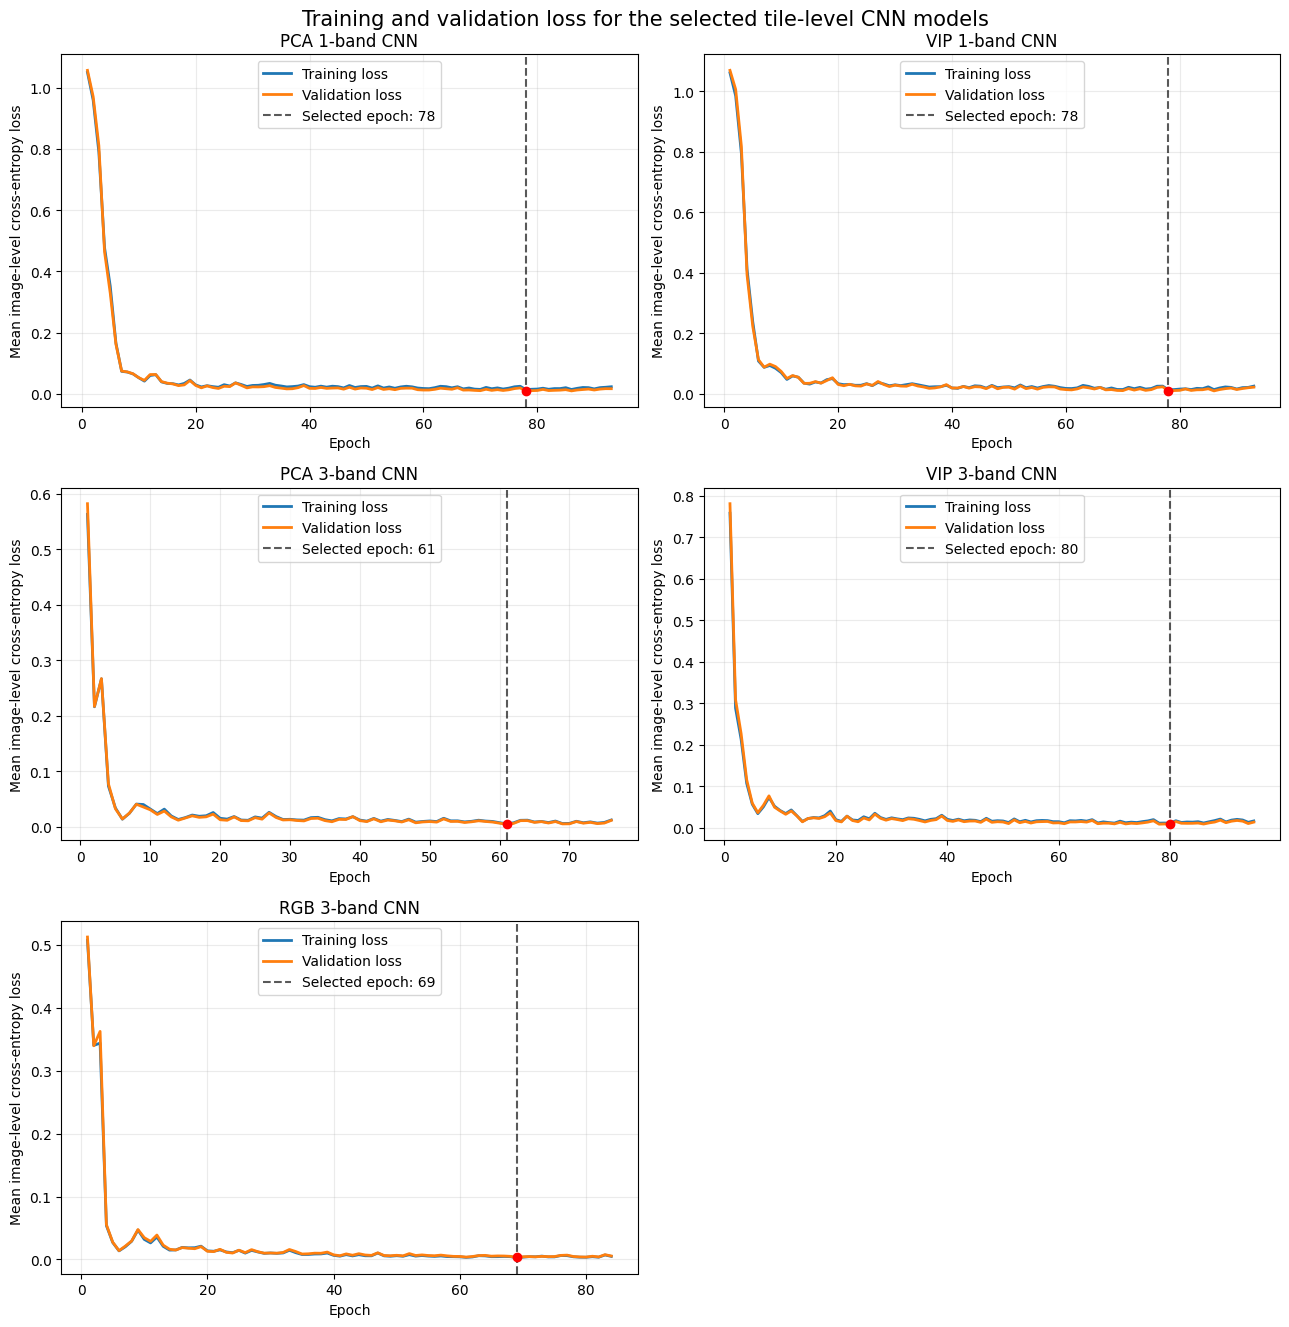

Saved loss curves to: spatial_results_resnet18_image_level/final_model_loss_curves.png


In [ ]:
# Plot the tile-level training and validation loss curves

n_models = len(
    all_spatial_results
)

n_cols = 2

n_rows = int(
    np.ceil(
        n_models
        / n_cols
    )
)


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        13,
        4.5 * n_rows
    ),
    squeeze=False
)


axes = axes.ravel()


for (
    ax,
    (
        experiment_name,
        result
    )
) in zip(
    axes,
    all_spatial_results.items()
):

    history_df = result[
        "history"
    ]

    ax.plot(
        history_df[
            "epoch"
        ],
        history_df[
            "train_tile_loss"
        ],
        label="Training tile loss",
        linewidth=2
    )

    ax.plot(
        history_df[
            "epoch"
        ],
        history_df[
            "valid_tile_loss"
        ],
        label="Validation tile loss",
        linewidth=2
    )

    ax.axvline(
        result[
            "best_epoch"
        ],
        linestyle="--",
        label=(
            f"Selected epoch "
            f"{result['best_epoch']}"
        )
    )

    ax.set_title(
        experiment_name
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Tile cross-entropy loss"
    )

    ax.legend()


for ax in axes[
    n_models:
]:
    ax.set_visible(
        False
    )


fig.suptitle(
    "ResNet18 tile training and validation loss",
    fontsize=15
)


plt.tight_layout()


loss_plot_path = (
    FIGURE_DIR
    / "resnet18_tile_loss_curves.png"
)


plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved loss curves to:",
    loss_plot_path
)


Final test evaluation: PCA 1-band CNN
Preloading train bags for wavelengths [491.9]
Preloading valid bags for wavelengths [491.9]
Preloading test bags for wavelengths [491.9]
Tile accuracy: 1.0000
Image majority-vote accuracy: 1.0000
Image balanced accuracy: 1.0000
Image macro F1: 1.0000


,precision,recall,f1-score,support
barley,1.0,1.0,1.0,3.0
corn,1.0,1.0,1.0,3.0
flax,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


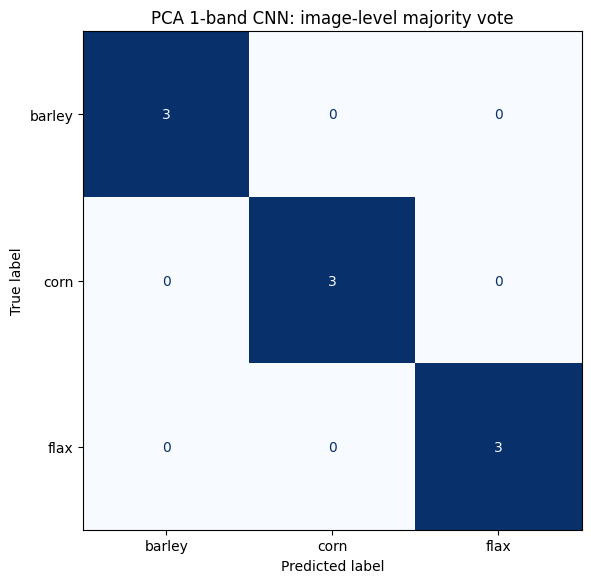


Final test evaluation: VIP 1-band CNN
Preloading train bags for wavelengths [497.2]
Preloading valid bags for wavelengths [497.2]
Preloading test bags for wavelengths [497.2]
Tile accuracy: 1.0000
Image majority-vote accuracy: 1.0000
Image balanced accuracy: 1.0000
Image macro F1: 1.0000


,precision,recall,f1-score,support
barley,1.0,1.0,1.0,3.0
corn,1.0,1.0,1.0,3.0
flax,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


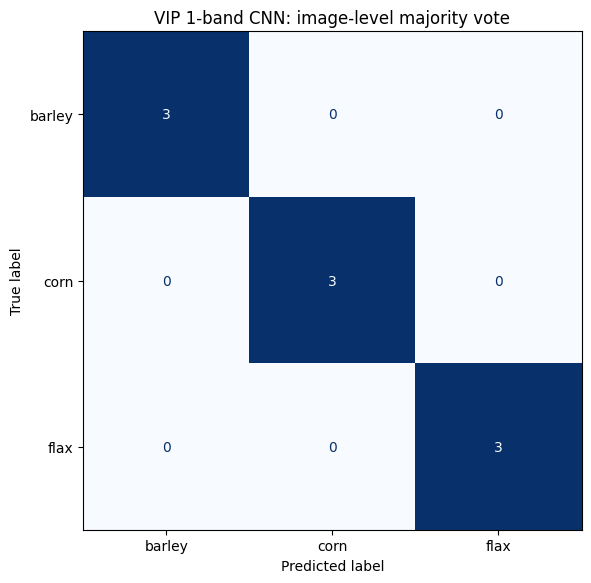


Final test evaluation: PCA 3-band CNN
Preloading train bags for wavelengths [491.9, 611.9, 641.6]
Preloading valid bags for wavelengths [491.9, 611.9, 641.6]
Preloading test bags for wavelengths [491.9, 611.9, 641.6]
Tile accuracy: 1.0000
Image majority-vote accuracy: 1.0000
Image balanced accuracy: 1.0000
Image macro F1: 1.0000


,precision,recall,f1-score,support
barley,1.0,1.0,1.0,3.0
corn,1.0,1.0,1.0,3.0
flax,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


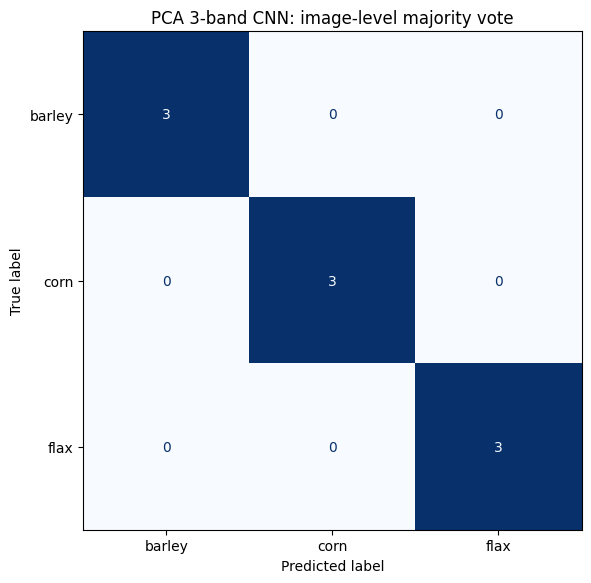


Final test evaluation: VIP 3-band CNN
Preloading train bags for wavelengths [497.2, 609.2, 641.6]
Preloading valid bags for wavelengths [497.2, 609.2, 641.6]
Preloading test bags for wavelengths [497.2, 609.2, 641.6]
Tile accuracy: 1.0000
Image majority-vote accuracy: 1.0000
Image balanced accuracy: 1.0000
Image macro F1: 1.0000


,precision,recall,f1-score,support
barley,1.0,1.0,1.0,3.0
corn,1.0,1.0,1.0,3.0
flax,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


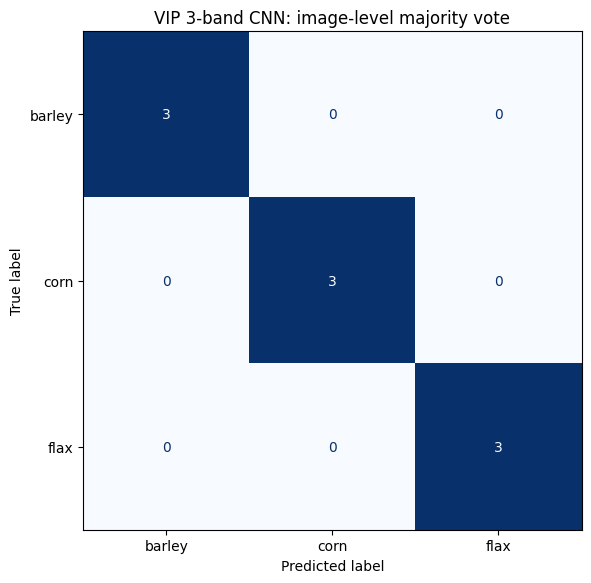


Final test evaluation: RGB 3-band CNN
Preloading train bags for wavelengths [650.0, 530.0, 450.0]
Preloading valid bags for wavelengths [650.0, 530.0, 450.0]
Preloading test bags for wavelengths [650.0, 530.0, 450.0]
Tile accuracy: 1.0000
Image majority-vote accuracy: 1.0000
Image balanced accuracy: 1.0000
Image macro F1: 1.0000


,precision,recall,f1-score,support
barley,1.0,1.0,1.0,3.0
corn,1.0,1.0,1.0,3.0
flax,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,9.0
weighted avg,1.0,1.0,1.0,9.0


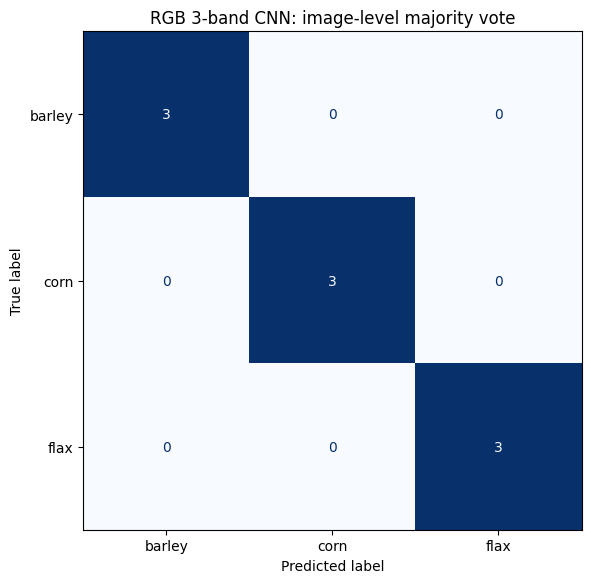

,experiment,test_tile_accuracy,test_tile_balanced_accuracy,test_tile_macro_f1,test_image_accuracy,test_image_balanced_accuracy,test_image_macro_f1
0,PCA 1-band CNN,1.0,1.0,1.0,1.0,1.0,1.0
1,VIP 1-band CNN,1.0,1.0,1.0,1.0,1.0,1.0
2,PCA 3-band CNN,1.0,1.0,1.0,1.0,1.0,1.0
3,VIP 3-band CNN,1.0,1.0,1.0,1.0,1.0,1.0
4,RGB 3-band CNN,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Evaluate tile predictions and image majority votes

def wilson_interval(
    correct,
    total,
    z=1.96
):
    """Calculate a Wilson accuracy interval"""

    if total == 0:
        return (
            np.nan,
            np.nan
        )

    proportion = (
        correct
        / total
    )

    denominator = (
        1
        + z**2 / total
    )

    centre = (
        proportion
        + z**2
        / (2 * total)
    ) / denominator

    margin = (
        z
        * np.sqrt(
            proportion
            * (1 - proportion)
            / total
            + z**2
            / (4 * total**2)
        )
        / denominator
    )

    return (
        centre - margin,
        centre + margin
    )


test_records = []


assert (
    SPATIAL_CONTROL_MODE
    == "image"
)


for (
    experiment_name,
    result
) in all_spatial_results.items():

    print(
        "\n"
        + "=" * 90
    )

    print(
        "Final test evaluation:",
        experiment_name
    )

    print(
        "=" * 90
    )

    channel_mean = np.asarray(
        result[
            "channel_mean"
        ],
        dtype=np.float32
    )

    channel_std = np.asarray(
        result[
            "channel_std"
        ],
        dtype=np.float32
    )

    test_datasets = make_datasets(
        target_wavelengths=(
            result[
                "target_wavelengths"
            ]
        ),
        channel_mean=channel_mean,
        channel_std=channel_std,
        include_test=True,
        preload=True,
        input_mode=(
            SPATIAL_CONTROL_MODE
        )
    )

    (
        _,
        _,
        _,
        test_loader
    ) = make_loaders(
        test_datasets,
        image_batch_size=(
            IMAGES_PER_BATCH
        ),
        seed=result[
            "seed"
        ]
    )

    (
        test_image_df,
        test_tile_df
    ) = predict_tile_vote(
        result["model"],
        test_loader,
        test_files_run
    )

    image_true = test_image_df[
        "true_class"
    ]

    image_pred = test_image_df[
        "predicted_class"
    ]

    tile_true = test_tile_df[
        "true_class"
    ]

    tile_pred = test_tile_df[
        "predicted_class"
    ]

    image_accuracy = accuracy_score(
        image_true,
        image_pred
    )

    image_balanced_accuracy = (
        balanced_accuracy_score(
            image_true,
            image_pred
        )
    )

    image_macro_f1 = f1_score(
        image_true,
        image_pred,
        average="macro",
        zero_division=0
    )

    tile_accuracy = accuracy_score(
        tile_true,
        tile_pred
    )

    tile_balanced_accuracy = (
        balanced_accuracy_score(
            tile_true,
            tile_pred
        )
    )

    tile_macro_f1 = f1_score(
        tile_true,
        tile_pred,
        average="macro",
        zero_division=0
    )

    correct_images = int(
        test_image_df[
            "correct"
        ].sum()
    )

    total_images = len(
        test_image_df
    )

    (
        confidence_low,
        confidence_high
    ) = wilson_interval(
        correct_images,
        total_images
    )

    safe_name = make_safe_name(
        experiment_name
    )

    test_image_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_test_images.csv"
        ),
        index=False
    )

    test_tile_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_test_tiles.csv"
        ),
        index=False
    )

    image_report_df = pd.DataFrame(
        classification_report(
            image_true,
            image_pred,
            labels=list(
                range(
                    len(varieties)
                )
            ),
            target_names=varieties,
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    image_report_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_image_test_report.csv"
        )
    )

    tile_report_df = pd.DataFrame(
        classification_report(
            tile_true,
            tile_pred,
            labels=list(
                range(
                    len(varieties)
                )
            ),
            target_names=varieties,
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    tile_report_df.to_csv(
        FINAL_MODEL_DIR
        / (
            f"{safe_name}"
            "_tile_test_report.csv"
        )
    )

    image_confusion = confusion_matrix(
        image_true,
        image_pred,
        labels=list(
            range(
                len(varieties)
            )
        )
    )

    image_display = (
        ConfusionMatrixDisplay(
            confusion_matrix=(
                image_confusion
            ),
            display_labels=(
                varieties
            )
        )
    )

    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    image_display.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(
        f"{experiment_name} image majority vote"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / (
            f"{safe_name}"
            "_image_confusion_matrix.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    tile_confusion = confusion_matrix(
        tile_true,
        tile_pred,
        labels=list(
            range(
                len(varieties)
            )
        )
    )

    tile_display = (
        ConfusionMatrixDisplay(
            confusion_matrix=(
                tile_confusion
            ),
            display_labels=(
                varieties
            )
        )
    )

    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    tile_display.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(
        f"{experiment_name} tile predictions"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / (
            f"{safe_name}"
            "_tile_confusion_matrix.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    result.update({
        "test_correct_images": (
            correct_images
        ),
        "test_total_images": (
            total_images
        ),
        "test_image_accuracy": (
            image_accuracy
        ),
        "test_image_balanced_accuracy": (
            image_balanced_accuracy
        ),
        "test_image_macro_f1": (
            image_macro_f1
        ),
        "test_accuracy_ci_low": (
            confidence_low
        ),
        "test_accuracy_ci_high": (
            confidence_high
        ),
        "test_tile_accuracy": (
            tile_accuracy
        ),
        "test_tile_balanced_accuracy": (
            tile_balanced_accuracy
        ),
        "test_tile_macro_f1": (
            tile_macro_f1
        )
    })

    test_records.append({
        "experiment": (
            experiment_name
        ),
        "correct_images": (
            correct_images
        ),
        "total_images": (
            total_images
        ),
        "image_accuracy": (
            image_accuracy
        ),
        "image_balanced_accuracy": (
            image_balanced_accuracy
        ),
        "image_macro_f1": (
            image_macro_f1
        ),
        "accuracy_ci_low": (
            confidence_low
        ),
        "accuracy_ci_high": (
            confidence_high
        ),
        "tile_accuracy": (
            tile_accuracy
        ),
        "tile_balanced_accuracy": (
            tile_balanced_accuracy
        ),
        "tile_macro_f1": (
            tile_macro_f1
        )
    })

    print(
        f"Correct source images: "
        f"{correct_images}/"
        f"{total_images}"
    )

    print(
        f"Tile accuracy: "
        f"{tile_accuracy:.3f}"
    )

    print(
        f"Image majority vote accuracy: "
        f"{image_accuracy:.3f}"
    )

    print(
        f"95% Wilson interval: "
        f"[{confidence_low:.3f}, "
        f"{confidence_high:.3f}]"
    )

    del test_datasets
    del test_loader

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


test_results_df = pd.DataFrame(
    test_records
)


test_results_df.to_csv(
    FINAL_MODEL_DIR
    / "final_resnet18_tile_vote_test_results.csv",
    index=False
)


display(
    test_results_df
)

In [ ]:
# Compare the final ResNet18 tile classifiers

summary_df = pd.DataFrame([
    {
        "method": (
            experiment_name
        ),
        "bands_nm": (
            result[
                "target_wavelengths"
            ]
        ),
        "n_bands": len(
            result[
                "target_wavelengths"
            ]
        ),
        "architecture": (
            "ImageNet pretrained ResNet18"
        ),
        "input_mode": (
            "complete standardised tiles"
        ),
        "loss_level": (
            "tile"
        ),
        "aggregation": (
            "majority vote"
        ),
        "tie_break": (
            "mean class probability"
        ),
        "fine_tuning": (
            "frozen ImageNet backbone with classifier head training"
        ),
        "tile_layout": (
            f"{N_ROWS}x{N_COLS}"
        ),
        "tiles_per_image": (
            TILES_PER_IMAGE
        ),
        "head_learning_rate": (
            result[
                "head_learning_rate"
            ]
        ),
        "weight_decay": (
            result[
                "weight_decay"
            ]
        ),
        "dropout": (
            result[
                "dropout"
            ]
        ),
        "label_smoothing": (
            result[
                "label_smoothing"
            ]
        ),
        "best_epoch": (
            result[
                "best_epoch"
            ]
        ),
        "validation_tile_accuracy": (
            result[
                "valid_tile_accuracy"
            ]
        ),
        "validation_image_accuracy": (
            result[
                "valid_image_accuracy"
            ]
        ),
        "validation_image_balanced_accuracy": (
            result[
                "valid_image_balanced_accuracy"
            ]
        ),
        "validation_image_macro_f1": (
            result[
                "valid_image_macro_f1"
            ]
        ),
        "test_tile_accuracy": (
            result[
                "test_tile_accuracy"
            ]
        ),
        "test_tile_balanced_accuracy": (
            result[
                "test_tile_balanced_accuracy"
            ]
        ),
        "test_tile_macro_f1": (
            result[
                "test_tile_macro_f1"
            ]
        ),
        "test_correct_images": (
            result[
                "test_correct_images"
            ]
        ),
        "test_total_images": (
            result[
                "test_total_images"
            ]
        ),
        "test_image_accuracy": (
            result[
                "test_image_accuracy"
            ]
        ),
        "test_image_balanced_accuracy": (
            result[
                "test_image_balanced_accuracy"
            ]
        ),
        "test_image_macro_f1": (
            result[
                "test_image_macro_f1"
            ]
        ),
        "test_accuracy_ci_low": (
            result[
                "test_accuracy_ci_low"
            ]
        ),
        "test_accuracy_ci_high": (
            result[
                "test_accuracy_ci_high"
            ]
        )
    }
    for (
        experiment_name,
        result
    ) in all_spatial_results.items()
])


summary_df = (
    summary_df
    .sort_values(
        [
            "test_image_balanced_accuracy",
            "test_image_macro_f1",
            "test_tile_accuracy"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


summary_df.to_csv(
    FINAL_MODEL_DIR
    / "final_resnet18_tile_vote_comparison.csv",
    index=False
)


display(
    summary_df
)

,method,bands_nm,n_bands,architecture,input_mode,tile_layout,tile_dimensions,tiles_per_image,images_per_batch,head_learning_rate,...,train_image_accuracy,validation_tile_accuracy,validation_image_accuracy,test_tile_accuracy,test_tile_balanced_accuracy,test_tile_macro_f1,test_image_accuracy,test_image_balanced_accuracy,test_image_macro_f1,aggregation
0,PCA 1-band CNN,[491.9],1,Genuine torchvision ResNet18 with mean feature...,foreground_only,4x4,220x180,16,2,0.00003,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,majority vote over 16 tile predictions with me...
1,VIP 1-band CNN,[497.2],1,Genuine torchvision ResNet18 with mean feature...,foreground_only,4x4,220x180,16,2,0.00003,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,majority vote over 16 tile predictions with me...
2,PCA 3-band CNN,"[491.9, 611.9, 641.6]",3,Genuine torchvision ResNet18 with mean feature...,foreground_only,4x4,220x180,16,2,0.00010,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,majority vote over 16 tile predictions with me...
3,VIP 3-band CNN,"[497.2, 609.2, 641.6]",3,Genuine torchvision ResNet18 with mean feature...,foreground_only,4x4,220x180,16,2,0.00005,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,majority vote over 16 tile predictions with me...
4,RGB 3-band CNN,"[650.0, 530.0, 450.0]",3,Genuine torchvision ResNet18 with mean feature...,foreground_only,4x4,220x180,16,2,0.00010,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,majority vote over 16 tile predictions with me...
